# Duplicates videos

In [1]:
import pandas as pd
df = pd.read_csv('/Users/van/Desktop/raw_data_1.csv').drop(columns = 'NZR - Paid campaign name (Short)')

In [2]:
df.columns.to_list()

['NZR - Year',
 'NZR - Page Name',
 'NZR - Platform Code',
 'NZR - Media Type',
 'NZR - Content Hierarchy L0',
 'NZR - Content Hierarchy L1',
 'NZR - Content Hierarchy L2',
 'NZR - Post URL',
 'NZR - Post Content (Low Case)',
 'NZR - Cost (NZD)',
 'NZR - Views',
 'NZR - Hours',
 'NZR - Engagement',
 'Likes + Comments + Shares',
 'Short content',
 'Duplicate']

In [3]:
df.shape

(76577, 16)

In [4]:
from pandas.api.types import is_numeric_dtype

platforms=['IG','FB','TT','YT']

df_clean = df[df['NZR - Platform Code'].isin(platforms) & (df['NZR - Media Type'] == 'Short Video')]\
    .drop_duplicates() \
    .rename(columns = {'NZR - Post Content (Low Case)':'caption long', 'id':'post_id','NZR - Platform Code': 'platform_v1'})

df_clean['platform_v2'] = df_clean['platform_v1'].replace({
    'IG': 'Meta',
    'FB': 'Meta'
})

df_clean['caption'] = df_clean['caption long'].str[:200]

df_small = df_clean[['NZR - Post URL','caption','platform_v2']].drop_duplicates()

df_final = (
    df_small.groupby(['caption','platform_v2'], as_index=False, sort=False, dropna=False)
      .agg('first')
)

df_small['platform_v2'].value_counts() , (df_small['platform_v2'].value_counts() - df_final['platform_v2'].value_counts())

# #df_final.sample(5)
# #df_small.to_csv('small_1.csv', index=False)

(platform_v2
 Meta    9453
 TT      2138
 YT      1552
 Name: count, dtype: int64,
 platform_v2
 Meta    2728
 TT        84
 YT       615
 Name: count, dtype: int64)

In [5]:
df_clean['length'] = df_clean['caption long'].str.len()

df_meta = df_clean[df_clean['platform_v2'].isin(['Meta'])]

df_meta['length'].quantile(0.90)

#df_clean['NZR - Views'].quartile(0.90),df_clean['NZR - Views'].quartile(0.50)

np.float64(191.0)

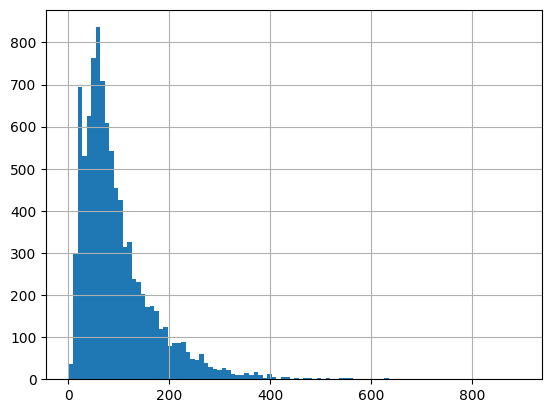

In [6]:
df_meta[df_meta['length']<1000]['length'].hist(bins=100);

In [8]:
from pandas.api.types import is_numeric_dtype

result = (
    df_small.groupby(['caption','platform_v2'], as_index=False, sort=False, dropna=False)
      .agg({column: 'sum' if is_numeric_dtype(df_small[column]) else 'first'
            for column in df_small.columns
            if column not in ['caption', 'counts']
           })
)

result['count'] = (
    df_small.groupby(['caption','platform_v2'], sort=False, dropna=False)
      .size()
      .to_numpy()
)

result.to_csv('small_3.csv', index=False)

In [9]:
df_processed = pd.read_csv("/Users/van/Desktop/processed.csv")
df_reduced = df_processed[['id','NZR - Post Content (Low Case)', 'description']].dropna().rename(columns = {'NZR - Post Content (Low Case)':'caption', 'id':'post_id'})

In [10]:
df_dict = df_reduced.to_dict(orient='records')

In [11]:
from pydantic import BaseModel, Field
from typing import Literal

ContentTheme = Literal[
    "training",
    "match_action",
    "haka",
    "preparation",
    "player_story",
    "rugby_skills",
    "rivalry",
    "celebration",
    "milestone",
    "team_selection",
    "other",
    "unclear",
]

FormatAccess = Literal[
    "highlight",
    "interview",
    "montage",
    "candid_clip",
    "announcement",
    "behind_the_scenes",
    "player_pov",
    "broadcast",
    "archival",
    "other",
    "unclear",
]

Tone = Literal[
    "humour",
    "excitement",
    "pride",
    "tension",
    "nostalgia",
    "inspiration",
    "warmth",
    "serious",
    "other",
    "unclear",
]

Context = Literal[
    "training_week",
    "pre_match",
    "match_day",
    "post_match",
    "off_season",
    "pitch",
    "gym",
    "changing_room",
    "stadium",
    "travel",
    "community_event",
    "other",
    "unclear",
]


class Entity(BaseModel):
    entity_type: Literal[
        "player",
        "coach",
        "team",
        "opponent",
        "fan",
        "alumni",
        "brand",
        "product",
        "other",
    ]
    entity_name: str | None


class PostClassification(BaseModel):
    post_id: str
    content_themes: list[ContentTheme] = Field(max_length=3)
    format_access: list[FormatAccess] = Field(max_length=2)
    people_entities: list[Entity]
    tones: list[Tone] = Field(bmax_length=2)
    contexts: list[Context] = Field(max_length=3)
    suggested_new_themes: list[str] = Field(max_length=3)
    classification_confidence: float = Field(ge=0, le=1)

In [12]:
df_reduced.shape
df_dict[50]

{'post_id': 'tt_7565291738936528148',
 'caption': 'our people in chicago 🖤 #chicago #rugby #allblacks ',
 'description': 'The video shows members of the New Zealand All Blacks rugby team interacting with fans at a "Takeover" fan event in Chicago. Throughout the video, players are seen walking in the city, signing autographs, posing for photos with fans of all ages in front of event backdrops, and observing fans enjoying activities and taking pictures with the Gallagher Cup trophy.'}

In [13]:
import json
from ollama import chat

post = df_dict[50]
response = chat(
    model="qwen3:4b",
    messages=[
    {
        "role": "system",
        "content": (
            "Classify All Blacks short-form social content. "
            "Use only observable evidence. Do not infer performance. "
            "Select only materially present labels."
        ),
    },
    {
        "role": "user",
        "content": json.dumps(post, ensure_ascii=False),
    },
    ],
    format=PostClassification.model_json_schema(),

    # Important for classification
    think=False,
    keep_alive="30m",
    stream=False,

    options={
        "temperature": 0,
        "num_ctx": 2048,
        "num_predict": 250,
    },
)

classification = PostClassification.model_validate_json(
    response.message.content
)

print(classification.model_dump())

{'post_id': 'tt_7561291738936528148', 'content_themes': ['team_selection', 'player_story', 'team_selection'], 'format_access': ['player_pov', 'player_pov'], 'people_entities': [{'entity_type': 'team', 'entity_name': 'New Zealand All Blacks rugby team'}, {'entity_type': 'team', 'entity_name': 'Chicago'}], 'tones': ['warmth', 'warmth'], 'contexts': ['community_event', 'community_event'], 'suggested_new_themes': ['team_unity', 'team_unity'], 'classification_confidence': 0.95}


In [14]:
from pydantic import BaseModel, Field


class VideoDescription(BaseModel):
    observable_summary: str

    opening_hook: str | None

    primary_actions: list[str] = Field(max_length=5)

    people_present: list[str] = Field(max_length=5)

    setting: list[str] = Field(max_length=3)

    production_format: list[str] = Field(max_length=3)

    apparent_tone: list[str] = Field(max_length=3)

    on_screen_text: list[str] = Field(max_length=10)
    
    visible_brands: list[str] = Field(max_length=5)

    uncertainties: list[str] = Field(max_length=5)

In [15]:
import cv2


def extract_frames(video_path, width=640):
    capture = cv2.VideoCapture(video_path)

    fps = capture.get(cv2.CAP_PROP_FPS)
    frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))

    if not fps or fps <= 0 or frame_count <= 0:
        capture.release()
        raise ValueError(f"Could not read video: {video_path}")

    duration = frame_count / fps

    # More frames near the beginning, then coverage across the video
    # timestamps = [
    #     0,
    #     min(0.5, duration),
    #     min(1.5, duration),
    #     min(3.0, duration),
    #     duration * 0.40,
    #     duration * 0.65,
    #     duration * 0.85,
    #     max(0, duration - 0.2),
    # ]
    timestamps = [
        0.2,
        min(1.5, duration),
        duration * 0.35,
        duration * 0.65,
        max(0, duration - 0.2),
    ]
    # Remove nearly duplicate timestamps
    timestamps = sorted({
        round(max(0, min(t, duration - 0.01)), 2)
        for t in timestamps
    })

    images = []

    for timestamp in timestamps:
        capture.set(cv2.CAP_PROP_POS_MSEC, timestamp * 1000)
        success, frame = capture.read()

        if not success:
            continue

        height, original_width = frame.shape[:2]

        if original_width > width:
            scale = width / original_width
            frame = cv2.resize(
                frame,
                (width, int(height * scale)),
            )

        success, encoded = cv2.imencode(
            ".jpg",
            frame,
            [cv2.IMWRITE_JPEG_QUALITY, 80],
        )

        if success:
            images.append(encoded.tobytes())

    capture.release()
    return images, timestamps

In [27]:
import json
from ollama import chat


SYSTEM_PROMPT = """
You describe short-form rugby social-media videos for later content analysis.

The supplied images are frames in chronological order.

Describe only what is observable in the frames or explicitly stated in the
caption and transcript.

Rules:
- Do not infer player identities unless a name is supplied or clearly visible.
- Do not infer whether a post is sponsored merely from incidental branding.
- Separate visible evidence from uncertainty.
- Describe the opening hook using the first frames.
- Keep the summary factual and concise.
- Do not predict views, engagement or audience response.
"""


def describe_video(
    video_path,
    caption="",
    transcript="",
):
    images, timestamps = extract_frames(video_path,width=512 )

    user_input = {
        "caption": caption,
        "transcript": transcript,
        "frame_timestamps_seconds": timestamps,
    }

    response = chat(
        model="qwen3-vl:4b-instruct",
        messages=[
            {
                "role": "system",
                "content": SYSTEM_PROMPT,
            },
            {
                "role": "user",
                "content": json.dumps(
                    user_input,
                    ensure_ascii=False,
                ),
                "images": images,
            },
        ],
        format=VideoDescription.model_json_schema(),
        think=False,
        keep_alive="30m",
        stream=False,
        options={
            "temperature": 0,
            "num_ctx": 12288,
            "num_predict": 700,
        },
    )




        
    # Insert the diagnostic check here
    content = (response.message.content or "").strip()
    thinking = (response.message.thinking or "").strip()
    
    print("Done reason:", response.done_reason)
    print("Content length:", len(content))
    print("Thinking length:", len(thinking))
    print("Content:", repr(content[:500]))
    print("Thinking:", repr(thinking[:500]))
    
    if not content:
        raise RuntimeError(
            "Ollama returned empty content. "
            f"done_reason={response.done_reason!r}, "
            f"thinking_length={len(thinking)}"
        )
    
    # Only validate after confirming that content is not empty
    result = VideoDescription.model_validate_json(content)
    
    print(result.model_dump())



    # result = VideoDescription.model_validate_json(
    #     response.message.content
    # )

    # return result



In [28]:
description = describe_video(
    video_path="/Users/van/Desktop/Test Video 2.mp4"
)

print(
    json.dumps(
        description.model_dump(),
        indent=2,
        ensure_ascii=False,
    )
)

KeyboardInterrupt: 